In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [13]:
# 2. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

In [22]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [14]:
print(f"Features shape: {X.shape}") # Should be (150, 4)
print(f"Target labels: {iris.target_names}") # Should be setosa, versicolor, virginica

Features shape: (150, 4)
Target labels: ['setosa' 'versicolor' 'virginica']


In [15]:
# Split data: 75% for training, 25% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [16]:
# Initialize and train the model
model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [17]:
# Get predictions for the test set
y_pred = model.predict(X_test)

In [18]:
# Calculate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate specific metrics
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
# 'macro' average is used because we have 3 species (classes)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

# Display the results
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {accuracy:.2f}")
print(f"Error Rate: {error_rate:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Confusion Matrix:
 [[13  0  0]
 [ 0 16  0]
 [ 0  0  9]]
Accuracy: 1.00
Error Rate: 0.00
Precision: 1.00
Recall: 1.00


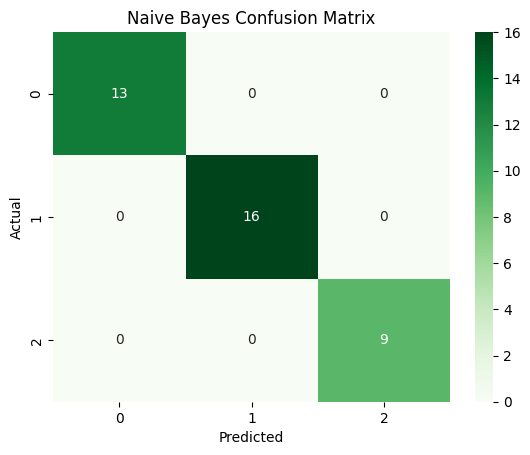

In [19]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

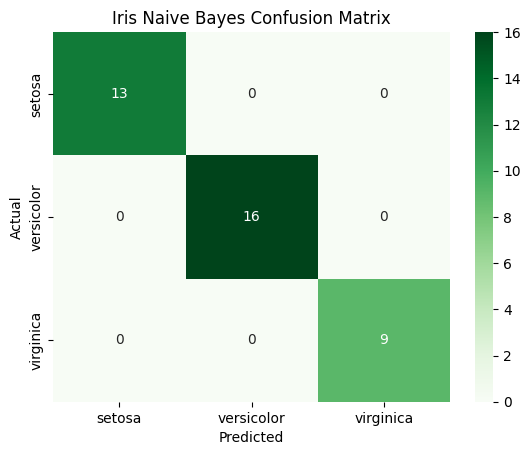

In [20]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Iris Naive Bayes Confusion Matrix')
plt.show()

In [ ]:
# 1. Define new sample data (Sepal Length, Sepal Width, Petal Length, Petal Width)
# Example: A flower with measurements [5.1, 3.5, 1.4, 0.2]
new_data = [[5.1, 3.5, 1.4, 0.2], [6.7, 3.0, 5.2, 2.3]]

# 2. Use the model to predict the class
predictions = model.predict(new_data)

# 3. Map the numerical results back to species names
print("Predictions for new samples:")
for i, pred in enumerate(predictions):
    species_name = iris.target_names[pred]
    print(f"Sample {i+1} measurements {new_data[i]} -> Predicted Species: {species_name}")